# Basic  Magnetostatic Simulation of a Flux Line

### Qiskit Metal Design

In [1]:
%reload_ext autoreload
%autoreload 2

import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings
import pyEPR as epr
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
#
from SQDMetal.Comps.Xmon import Xmon
from SQDMetal.Comps.Capacitors import CapacitorGapPinStretch
from SQDMetal.Comps.Wires import WireTaperPinStretch, WirePinStretch
from SQDMetal.Comps.FluxLines import FluxLineTPin
from SQDMetal.Comps.Junctions import JunctionDolanPinStretch

design = designs.DesignPlanar({}, True)
design.chips.main.size['size_x'] = '400um'
design.chips.main.size['size_y'] = '400um'

Xmon(design, 'leXmon', options=Dict(pos_x=0, pos_y=0,
                                    vBar_width='24um', hBar_width='24um', vBar_gap='16um', hBar_gap='16um',
                                    cross_width='144um', cross_height='144um',
                                    gap_up='24um', gap_left='0um', gap_right='24um'))

FluxLineTPin(design, 'flux_line_T', options=Dict(ref_comp='leXmon', ref_pin='right',
                                                 width=f'100um',
                                                 trace_width=f'8um',
                                                 trace_gap=f'12um',pin_dist='24um'))
WireTaperPinStretch(design, 'flux_ln_taper', options=Dict(pin_inputs={'start_pin': {'component': 'flux_line_T', 'pin': 'a'}},
                                                   trace_width=f'20um', trace_gap=f'28um', taper_length='50um'))
WirePinStretch(design, 'flux_ln_wire', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'flux_ln_taper',pin='a')),
                                                    dist_extend='54um', trace_width=f'20um', trace_gap=f'28um'))
CapacitorGapPinStretch(design, f'capProng', options=Dict(cpw_width=f'20um',
                                            pin_inputs=Dict(start_pin=Dict(component=f'leXmon',pin='left')),
                                            dist_extend='120um',
                                            cap_width=f'50um',
                                            cap_gap='3um',
                                            gnd_width='1um',
                                            len_diag='0um', len_flat=f'50um',
                                            side_gap=f'10um', init_pad='10um'
                                            ))

############################
JunctionDolanPinStretch(design, 'junction', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'flux_line_T',pin='t')),
                                                         dist_extend='25um',
                                                         finger_width='0.4um', t_pad_size='0.385um',
                                                         squid_width='5.4um', prong_width='0.9um',
                                                         layer=2));
############################


# gui = MetalGUI(design)
# gui.rebuild()
# gui.autoscale()

The idea is to run this through a shadow-evaporated Josephson junction (notice that `'junction'` is in layer 2). So let's quickly do the PVD simulation to ensure that there is an enclosed loop:

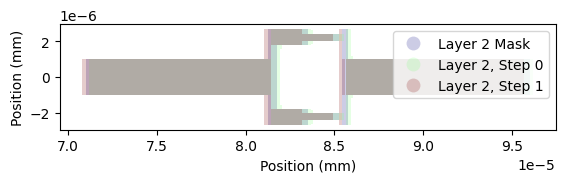

In [2]:
from SQDMetal.Utilities.PVD_Shadows import PVD_Shadows
%matplotlib inline
design.chips['main']['evaporations'] = Dict(
    layer2=Dict(
        bottom_layer='200nm',
        top_layer='100nm',
        undercut='200nm',
        pvd1 = Dict(
        angle_phi = '0',
        angle_theta = '-45',
        metal_thickness = '20nm'
        ),
        pvd2 = Dict(
        angle_phi = '0',
        angle_theta = '45'
        )
    )
)
pvdSh = PVD_Shadows(design)
pvdSh.plot_layer(2,'separate', plot_mask=True)

We can extract the largest interior area for surface flux integration

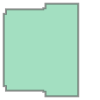

In [3]:
int_area = pvdSh.get_shadow_largest_interior_for_component('junction')[1]
int_area

### Magnetostatic Simulation

Now to run the Palace simulation (*make sure to update the path to the Palace binary first*)

In [ ]:
from SQDMetal.PALACE.Inductance_Simulation import PALACE_Inductance_Simulation

#Eigenmode Simulation Options
user_defined_options = {
                "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solver_order": 2,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-8,                              #error residual tolerance for iterative solver
                "solver_maxits": 200,                              #number of solver iterations
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "palace_dir":"~/spack/opt/spack/linux-ubuntu24.04-zen2/gcc-13.3.0/palace-develop-36rxmgzatchgymg5tcbfz3qrmkf4jnmj/bin/palace",#"PATH/TO/PALACE/BINARY",
                "num_cpus": 16
                }

#Create the Palace Eigenmode simulation
mag_sim = PALACE_Inductance_Simulation(name ='Test1',                                              #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'                                          
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh and config files

#add in metals from the first layer
mag_sim.add_metallic(1)
mag_sim.add_metallic(2, evap_mode=None)

#add ground plane into simulation
mag_sim.add_ground_plane()

#Create a lumped element port for the Josephson junction and assign Jospehson inductance and junction capacitance
# mag_sim.create_port_JosephsonJunction('Q1', L_J = 11e-9, C_J = 0e-15)
mag_sim.create_current_source_with_Uclip_on_Route('flux_ln_wire', 'end')

mag_sim.add_integration_area(int_area)

#Fine mesh the qubit and resonator - min_size/max_size is the min/max mesh element size
mag_sim.fine_mesh_components(['junction', 'flux_ln_wire', 'flux_ln_taper'], min_size=5e-6, max_size=50e-6, taper_dist_min=20e-6, metals_only=True)
# mag_sim.fine_mesh_along_path(qObjName='readout', dist_resolution=10e-6, min_size=12e-6, max_size=150e-6, taper_dist_min=10e-6)

#Prepare the simulation files - mesh file (.msh) and config file (.json)
mag_sim.prepare_simulation()

In [5]:
mag_sim.open_mesh_gmsh()

In [ ]:
flux_per_amp = mag_sim.run()

The returned value is the flux per Ampere. We can normalise it to flux quanta for 1mA to get a reasonable estimate of the flux-tunability:

In [8]:
flux_per_amp / 2.067833848e-15 * 0.001

array([[0.02227944]])